### Упражнение 1

- Загрузите два временных ряда `stationarity_ts1` и `stationarity_ts2`, выполнив код ниже.

In [ ]:
# Load the first time series
response = requests.get("https://zenodo.org/records/10897398/files/stationarity_ts1.npy?download=1")
response.raise_for_status()
stationarity_ts1 = np.load(BytesIO(response.content))
print(len(stationarity_ts1))

# Load the second time series
response = requests.get("https://zenodo.org/records/10897398/files/stationarity_ts2.npy?download=1")
response.raise_for_status()
stationarity_ts2 = np.load(BytesIO(response.content))
print(len(stationarity_ts2))

100
100


1. Постройте два временных ряда с помощью графика последовательности запусков.
4. На основе графика обсудите, является ли каждый временной ряд стационарным или нет.

### Упражнение 2

Используйте следующие инструменты, чтобы определить, являются ли временные ряды `stationarity_ts1` и `stationarity_ts2` стационарными или нет.

1. Сводная статистика по фрагментам.
2. Гистограммы.
3. Расширенный тест Дики-Фуллера.

Обсудите результат, полученный с помощью каждого метода.

### Упражнение 3
Если один или оба набора данных из упражнений один и два нестационарны, примените преобразования, которые вы изучили в этом разделе, чтобы сделать их таковыми. Затем примените методы, которые вы изучили, чтобы обеспечить стационарность.

Критерии стационарности ряда

| № | Критерий                     | Проверка                          |
| - | ---------------------------- | --------------------------------- |
| 1 | Постоянное среднее           | График + разбивка на фрагменты    |
| 2 | Постоянная дисперсия         | График + статистика по фрагментам |
| 3 | Нет тренда                   | Визуально + регрессия             |
| 4 | Нет сезонности               | График + ACF/PACF                 |
| 5 | Постоянная автокорреляция    | ACF функция                       |
| 6 | Статистическое подтверждение | ADF тест (p < 0.05 → стационарен) |

# ---------------------------------------------------------

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

np.random.seed(0)

from io import BytesIO
import requests

### №1

In [3]:
response = requests.get("https://zenodo.org/records/10897398/files/stationarity_ts1.npy?download=1")
response.raise_for_status()
stationarity_ts1 = np.load(BytesIO(response.content))
print(len(stationarity_ts1))
    
response = requests.get("https://zenodo.org/records/10897398/files/stationarity_ts2.npy?download=1")
response.raise_for_status()
stationarity_ts2 = np.load(BytesIO(response.content))
print(len(stationarity_ts2))



100
100


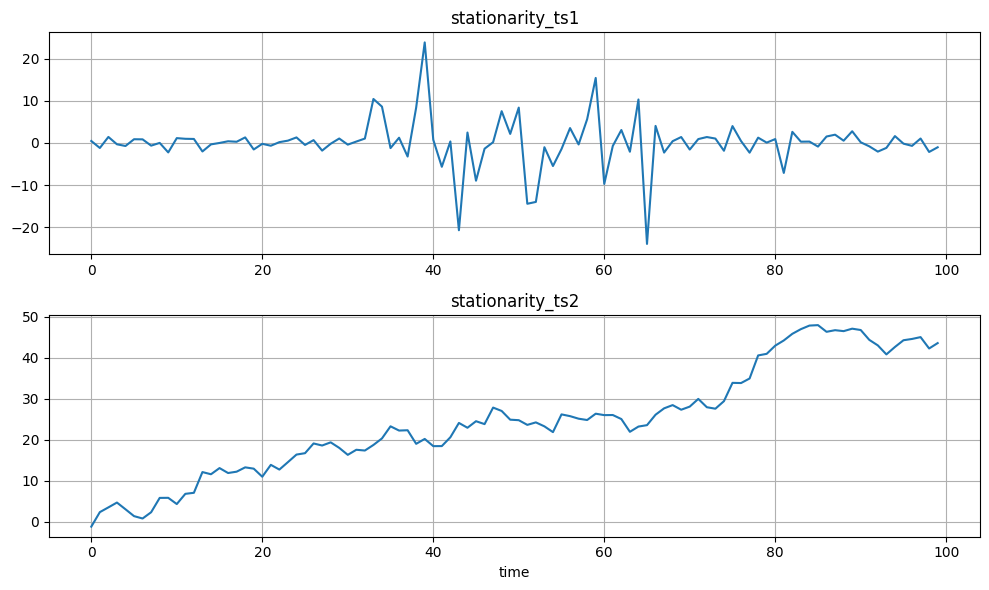

In [6]:
time = np.arange(len(stationarity_ts1))

fig, ax = plt.subplots(2, 1, figsize=(10, 6))

ax[0].plot(time, stationarity_ts1)
ax[0].set_title("stationarity_ts1")
ax[0].grid()

ax[1].plot(time, stationarity_ts2)
ax[1].set_title("stationarity_ts2")
ax[1].set_xlabel("time")
ax[1].grid()

plt.tight_layout()
plt.show()

на первом графике в области 40-65 по времени появляются резкие выбросы, дисперсия визуально неоднородна (скорее всего нестационарный)
на втором графике виден восходящий тренд, среднее растет, дисперсия растет - нестационарный

будем проверять в след упражнениях

### №2

СВОДНАЯ СТАТИСТИКА ПО ЭЛЕМЕНТАМ

In [7]:
chunks_ts1 = np.array_split(stationarity_ts1, 10)
chunks_ts2 = np.array_split(stationarity_ts2, 10)

print("stationarity_ts1:")
for i, chunk in enumerate(chunks_ts1, 1):
    print(f"{i}: mean={np.mean(chunk):.2f}, var={np.var(chunk):.2f}")

print("\nstationarity_ts2:")
for i, chunk in enumerate(chunks_ts2, 1):
    print(f"{i}: mean={np.mean(chunk):.2f}, var={np.var(chunk):.2f}")

stationarity_ts1:
1: mean=-0.14, var=1.11
2: mean=0.12, var=1.17
3: mean=0.05, var=0.77
4: mean=4.92, var=59.92
5: mean=-2.33, var=55.95
6: mean=-0.37, var=79.17
7: mean=-1.95, var=77.82
8: mean=0.35, var=3.19
9: mean=0.30, var=7.29
10: mean=-0.52, var=1.35

stationarity_ts2:
1: mean=2.82, var=4.50
2: mean=10.51, var=9.30
3: mean=16.02, var=7.52
4: mean=19.73, var=4.98
5: mean=23.27, var=9.43
6: mean=24.61, var=1.77
7: mean=25.54, var=3.96
8: mean=32.74, var=22.71
9: mean=46.29, var=2.22
10: mean=43.77, var=2.48


в ts1 прям видны резкие скачки в значениях mean (то что видели на графике, резкая дисперсия)
в ts2 mean идет на увеличени, монотонный рост среднего значения, возрастающий тренд, случайное блуждание

ГИСТОГРАММЫ

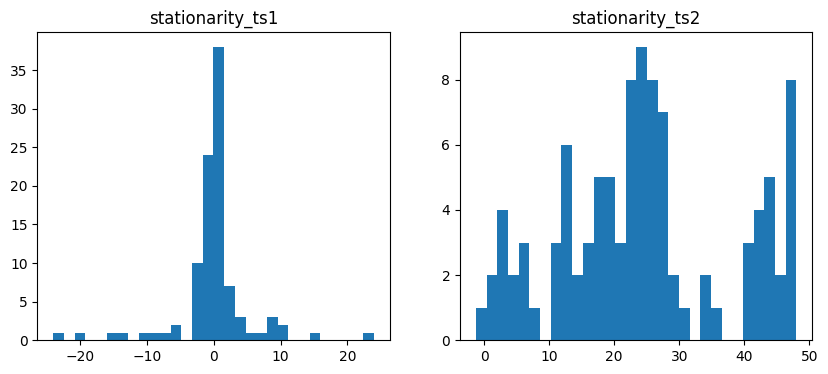

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(stationarity_ts1, bins=30)
ax[0].set_title("stationarity_ts1")
ax[1].hist(stationarity_ts2, bins=30)
ax[1].set_title("stationarity_ts2")
plt.show()

в ts1 видно большой хвост, оновная масса сконцентрирована где-то -5 до 5 (около нуля)
в ts2 широкое плоское распределение без центра (типично для рядов с трендом) - нестационарен

РАСШИРЕННЫЙ ТЕСТ

In [14]:
adf1, pvalue1, _, _, _, _ = adfuller(stationarity_ts1)
print(f"\nts1: ADF={adf1:.4f}, p-value={pvalue1:.4f}")

adf2, pvalue2, _, _, _, _ = adfuller(stationarity_ts2)
print(f"ts2: ADF={adf2:.4f}, p-value={pvalue2:.4f}")


ts1: ADF=-3.0324, p-value=0.0320
ts2: ADF=-1.3223, p-value=0.6189


по статистическому тесту:
ts1 p 0,032

### №3

ts1 декомпозиция

In [ ]:
decomp = seasonal_decompose(stationarity_ts1, model='additive', period=12)
residuals = decomp.resid[~np.isnan(decomp.resid)]

adf_res, pvalue_res, _, _, _, _ = adfuller(residuals)
print(f"ts1 после декомпозиции p-value={pvalue_res:.6f}")

ts1 после декомпозиции: p-value=0.000695


ts2 дифференцирование

In [11]:
ts2_diff = np.diff(stationarity_ts2)

adf_diff, pvalue_diff, _, _, _, _ = adfuller(ts2_diff)
print(f"ts2 после дифференцирования p-value={pvalue_diff:.6f}")

ts2 после дифференцирования p-value=0.000000


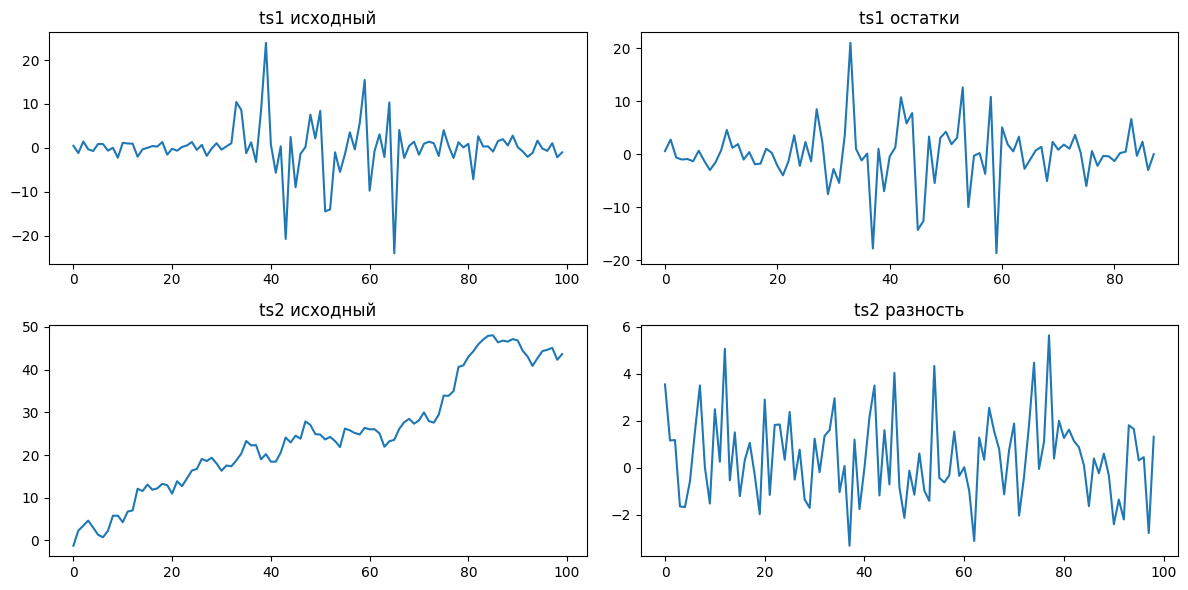

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(12, 6))

ax[0,0].plot(stationarity_ts1)
ax[0,0].set_title("ts1 исходный")
ax[0,1].plot(residuals)
ax[0,1].set_title("ts1 остатки")

ax[1,0].plot(stationarity_ts2)
ax[1,0].set_title("ts2 исходный")
ax[1,1].plot(ts2_diff)
ax[1,1].set_title("ts2 разность")

plt.tight_layout()
plt.show()